# Prompt Prediction Exact Agreement

Compare sample-level predictions across prompt types (`B1`, `B2`, `C1`, `C2`, `C3`, `A`, `R`), across judges, and against the gold labels and studied task-model predictions, using every judge whose generations have been parsed into `data/predictions_*.csv`.

The matrices report pairwise exact agreement between categorical class predictions. Class IDs are treated as unordered labels.

Inputs:
* `data/predictions_{judge}.csv` – produced by `scripts/parse_generations.py` from `data/generations/*.jsonl`.
* `data/sample_metadata.csv` - gold labels and task-model predictions used to fill the `real_label` and `model_prediction` columns.

To keep the cross-family baseline invariant (B1 / B2 byte-identical across concepts / rationales / attributions), this notebook uses the harmonized `new_consim`, `attributions`, and `rationales` specifications with non-anonymized prompt types, excluding `old_consim` and `simulator_consim`. It selects the attribution baseline as one deterministic baseline generation source and applies the same canonical three-class GoEmotions filter as the score analyses.

## 1. Parameters

In [1]:
# Prediction CSVs to load. None -> every predictions_*.csv under data/.
PREDICTIONS_FILES = None

# Optional filters. None keeps every available value.
JUDGES = None
DATASETS = None
CLASSES_SUBSETS = None

# Best-method allow-list per prompt type. Only rows matching these will populate
# the corresponding column in the exact-agreement matrix. Defaults match
# scripts/extract_best_prompts.py.
BEST_CONCEPT_METHOD = 'VanillaSAE'
BEST_CONCEPT_INTERPRETATION = 'topk'
BEST_ATTRIBUTION_METHOD = 'lime'
BEST_RATIONALE_METHODS = {'Qwen/Qwen3.5-2B', 'qwen3.5-2b'}
BASELINE_SPECIFICATION = 'attributions'

MIN_PAIRED_SAMPLES = 2  # skip strata with fewer paired predictions
EXPORT_FIGURES = False

## 2. Load and Reshape Predictions

In [2]:
from pathlib import Path
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils.analysis import keep_ge_class_subset_len

DATA_DIR = REPO_ROOT / 'data'
EXPORT_DIR = REPO_ROOT / 'outputs' / 'figures'

PROMPT_TYPE_ALIAS = {'B1': 'B1', 'B2': 'B2', 'C1': 'C1', 'C2': 'C2', 'C3': 'C3', 'A1': 'A', 'R1': 'R'}
LABEL_COLUMNS = ['real_label', 'model_prediction', 'B1', 'B2', 'C1', 'C2', 'C3', 'A', 'R']
PROMPT_COLUMNS = ['B1', 'B2', 'C1', 'C2', 'C3', 'A', 'R']
DISPLAY_NAMES = {
    'real_label': 'Gold',
    'model_prediction': 'Model',
    'Qwen/Qwen3.5-9B': 'Qwen 3.5-9B',
    'microsoft/phi-4': 'Phi-4',
    'google/gemma-4-12B-it': 'Gemma 4-12B',
    'meta-llama/Llama-3.1-8B-Instruct': 'Llama 3.1-8B',
}

prediction_paths = (
    [Path(path) for path in PREDICTIONS_FILES]
    if PREDICTIONS_FILES
    else sorted(DATA_DIR.glob('predictions_*.csv'))
)
assert prediction_paths, 'No predictions_*.csv files found; run scripts/parse_generations.py first.'
raw = pd.concat([pd.read_csv(path) for path in prediction_paths], ignore_index=True)

# Latest-wins dedup on the full identity (judge, thinking + 9-field prompt key).
# Handles the case where the same key was parsed from multiple generation logs.
key_columns = ['judge', 'thinking', 'dataset', 'model', 'classes_subset', 'seed', 'method', 'nb_concepts', 'interpretation', 'prompt_type', 'specification']
raw = raw.drop_duplicates(subset=key_columns, keep='last').reset_index(drop=True)

# Keep only prompt types the exact-agreement matrix uses; exclude old/simulator
# consim (which don't share the byte-identical baseline invariant across
# families). New-ConSim concepts live under specification='new_consim';
# attributions and rationales use their own specifications with matching
# byte-identical B1/B2 baselines.
keep_specifications = {'new_consim', 'attributions', 'rationales'}
raw = raw[raw['specification'].isin(keep_specifications)].copy()
raw = raw[raw['prompt_type'].isin(PROMPT_TYPE_ALIAS)].copy()
raw = keep_ge_class_subset_len(raw, 3)


In [3]:
# Restrict each prompt type to its selected best method/config.
def keep_row(row):
    prompt_type = row['prompt_type']
    method = row['method']
    interpretation = row['interpretation'] if pd.notna(row['interpretation']) else None
    if prompt_type in {'B1', 'B2'}:
        return method == 'baseline' and row['specification'] == BASELINE_SPECIFICATION
    if prompt_type in {'C1', 'C2', 'C3'}:
        return method == BEST_CONCEPT_METHOD and interpretation == BEST_CONCEPT_INTERPRETATION
    if prompt_type == 'A1':
        return method == BEST_ATTRIBUTION_METHOD
    if prompt_type == 'R1':
        return method in BEST_RATIONALE_METHODS
    return False

raw = raw[raw.apply(keep_row, axis=1)].copy()
raw['prompt_column'] = raw['prompt_type'].map(PROMPT_TYPE_ALIAS)

if JUDGES is not None:
    raw = raw[raw['judge'].isin(JUDGES)].copy()
if DATASETS is not None:
    raw = raw[raw['dataset'].isin(DATASETS)].copy()
if CLASSES_SUBSETS is not None:
    raw = raw[raw['classes_subset'].isin(CLASSES_SUBSETS)].copy()

In [4]:
# Melt sample columns to long form, keeping only samples that exist for the row
# (there are up to MAX_SAMPLES columns; unused ones are empty).
pred_columns = [c for c in raw.columns if c.startswith('pred_')]
id_columns = ['judge', 'thinking', 'dataset', 'model', 'classes_subset', 'seed', 'cache_n', 'prompt_column']
long = raw.melt(id_vars=id_columns, value_vars=pred_columns, var_name='sample_col', value_name='prediction')
long['sample_index'] = long['sample_col'].str.removeprefix('pred_').astype(int)
long = long.dropna(subset=['prediction']).copy()
long['prediction'] = pd.to_numeric(long['prediction'], errors='coerce').astype('Int64')
long = long.dropna(subset=['prediction'])  # drop any left-over invalid rows
long = long.drop(columns=['sample_col'])

In [5]:
# Published metadata supplies gold labels and task-model predictions for
# the cache slices represented in the prediction artifacts.
metadata_path = DATA_DIR / 'sample_metadata.csv'
assert metadata_path.exists(), f'No sample metadata found at {metadata_path}'
sample_metadata = pd.read_csv(metadata_path)


In [6]:
# One row per expected evaluation sample, including rows where every retained
# prompt prediction is invalid. cache_n is part of the sample identity.
row_key_columns = ['judge', 'thinking', 'dataset', 'model', 'classes_subset', 'seed', 'cache_n', 'sample_index']
wide = (
    long.groupby(row_key_columns + ['prompt_column'], as_index=False)['prediction']
        .last()
        .pivot(index=row_key_columns, columns='prompt_column', values='prediction')
        .reset_index()
)
expected_rows = (
    raw[['judge', 'thinking', 'dataset', 'model', 'classes_subset', 'seed', 'cache_n']]
    .drop_duplicates()
    .merge(
        sample_metadata[['dataset', 'classes_subset', 'seed', 'cache_n', 'sample_index']].drop_duplicates(),
        on=['dataset', 'classes_subset', 'seed', 'cache_n'],
        how='inner',
    )
)
wide = expected_rows.merge(wide, on=row_key_columns, how='left')
wide = wide.merge(
    sample_metadata[['dataset', 'classes_subset', 'seed', 'cache_n', 'sample_index', 'real_label', 'task_model_prediction']],
    on=['dataset', 'classes_subset', 'seed', 'cache_n', 'sample_index'],
    how='left',
)
wide = wide.rename(columns={'task_model_prediction': 'model_prediction'})
for column in LABEL_COLUMNS:
    if column not in wide.columns:
        wide[column] = pd.NA
    wide[column] = pd.to_numeric(wide[column], errors='coerce').astype('Int64')

## 4. Exact Agreement

Exact agreement is the percentage of pairwise-complete predictions with identical class labels. Class IDs are treated as **unordered categorical labels**, so results are invariant under any relabeling of the classes.

Each matrix cell is computed separately within the declared strata and then averaged with equal weight across strata.

In [7]:
def paired_exact_agreement(left, right):
    paired = pd.concat([left, right], axis=1).dropna()
    if paired.empty:
        return np.nan, 0
    score = paired.iloc[:, 0].eq(paired.iloc[:, 1]).mean()
    return float(score), len(paired)

def exact_agreement_matrix(frame, label_columns=LABEL_COLUMNS, strata_columns=('classes_subset',)):
    matrix = pd.DataFrame(np.nan, index=label_columns, columns=label_columns)
    group_key = strata_columns[0] if len(strata_columns) == 1 else list(strata_columns)
    for left in label_columns:
        for right in label_columns:
            per_stratum_scores = []
            for _stratum_key, stratum in frame.groupby(group_key, dropna=False):
                score, n_pairs = paired_exact_agreement(stratum[left], stratum[right])
                if n_pairs < MIN_PAIRED_SAMPLES:
                    continue
                if not np.isnan(score):
                    per_stratum_scores.append(score)
            if per_stratum_scores:
                # Equal-weight mean over strata: each stratum contributes once,
                # so a stratum with many pairs does not dominate.
                matrix.loc[left, right] = float(np.mean(per_stratum_scores))
    return matrix

def plot_agreement_matrix(matrix, output_slug=None):
    labels = [DISPLAY_NAMES.get(c, c) for c in matrix.index]
    values = matrix.to_numpy(dtype=float)
    fig, axis = plt.subplots(figsize=(3.35, 3.35))
    axis.imshow(values, cmap='coolwarm', vmin=0, vmax=1)
    axis.set_xticks(range(len(labels)), labels=labels, rotation=45, ha='right', fontsize=7)
    axis.set_yticks(range(len(labels)), labels=labels, fontsize=7)
    for row in range(len(labels)):
        for column in range(len(labels)):
            value = values[row, column]
            if not np.isnan(value):
                axis.text(column, row, f'{value:.0%}', ha='center', va='center', fontsize=6.5, color='black')
    fig.tight_layout()
    if EXPORT_FIGURES and output_slug is not None:
        EXPORT_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(EXPORT_DIR / f'prediction_exact_agreement_{output_slug}.pdf', bbox_inches='tight')
    plt.show()

## 5. Summary Exact-Agreement Matrix

Each cell of the matrix is computed separately for every **(`judge`, `dataset`, `classes_subset`) stratum** and then **averaged with equal weight** across the 40 paper strata. Pooling all prediction pairs would inject shared judge, dataset, and class-subset signals into every pair of prompt columns.

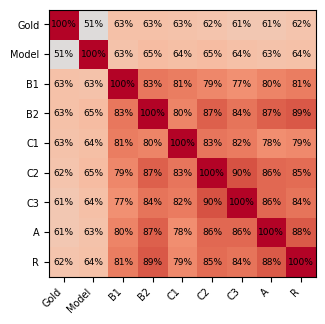

In [8]:
summary_matrix = exact_agreement_matrix(
    wide, strata_columns=('judge', 'dataset', 'classes_subset')
)
plot_agreement_matrix(summary_matrix, output_slug='summary')

## 6. Exact Agreement by Judge and Dataset

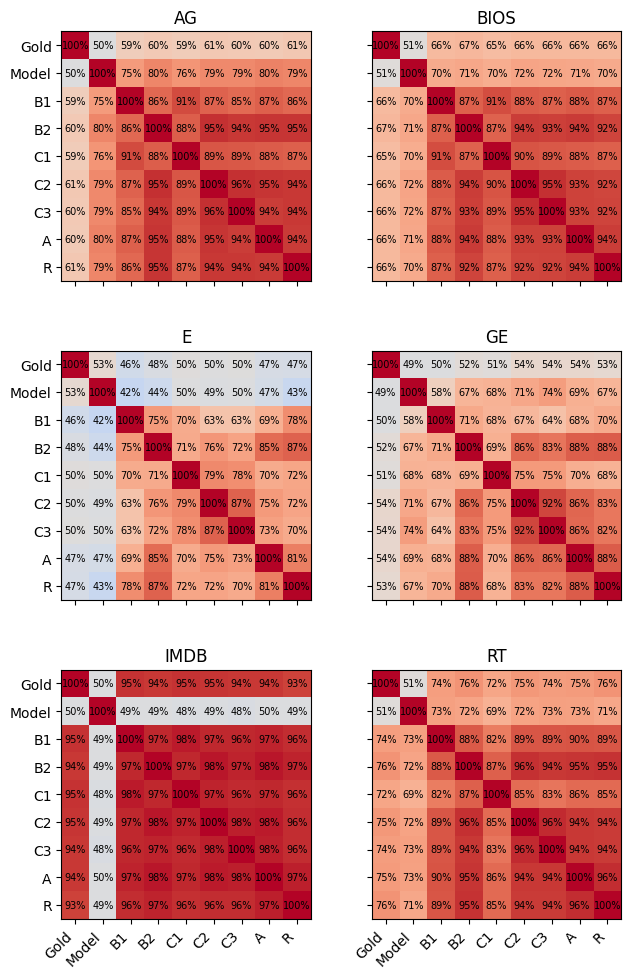

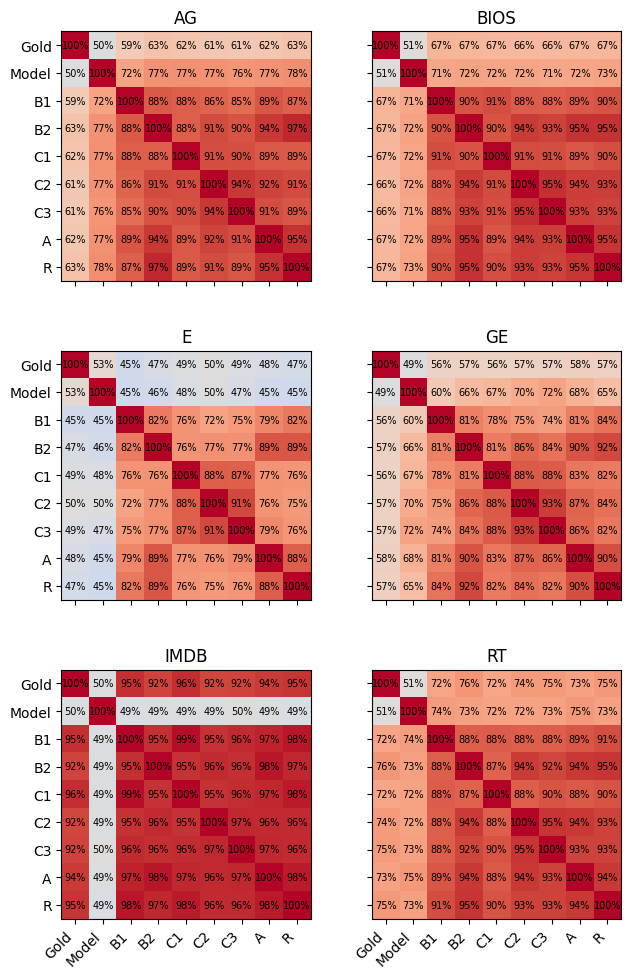

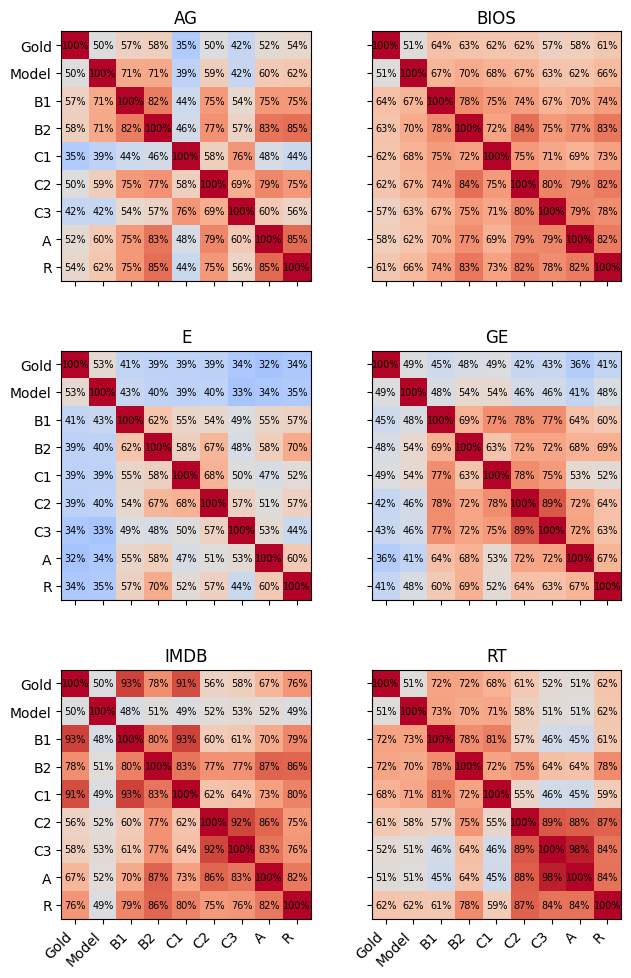

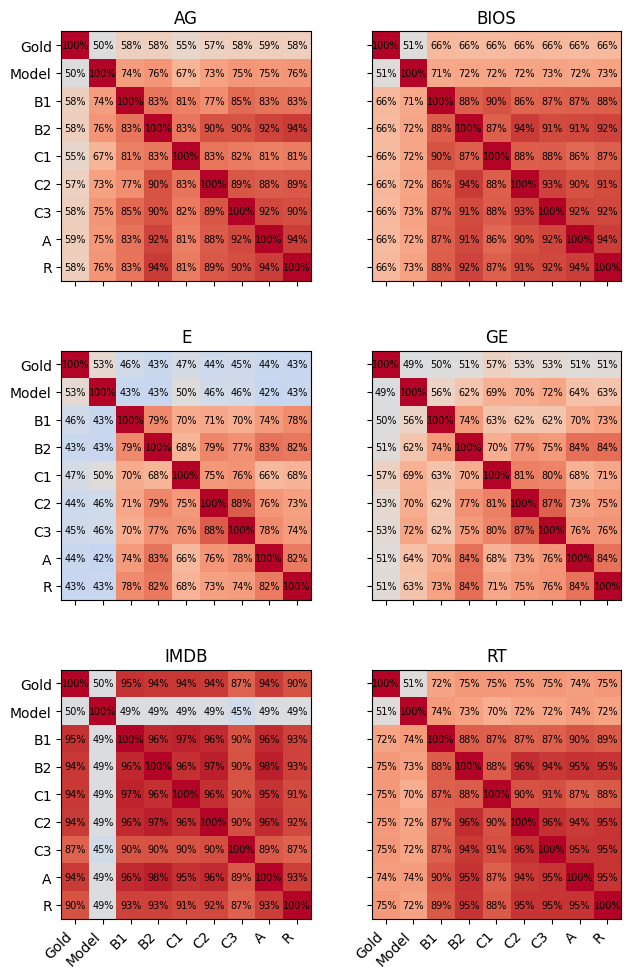

In [9]:
agreement_matrices = {}
for (judge, thinking, dataset), group in wide.groupby(['judge', 'thinking', 'dataset'], dropna=False):
    key = (judge, bool(thinking), dataset)
    agreement_matrices[key] = exact_agreement_matrix(group)

def plot_judge_agreement_matrices(judge, thinking):
    datasets = sorted(dataset for j, t, dataset in agreement_matrices if j == judge and t == thinking)
    if not datasets:
        return
    ncols = min(2, len(datasets))
    nrows = math.ceil(len(datasets) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(7, 3.4 * nrows), squeeze=False)
    fig.subplots_adjust(left=0.08, right=0.99, bottom=0.07, top=0.94, wspace=-0.05, hspace=0.28)
    labels = [DISPLAY_NAMES.get(c, c) for c in LABEL_COLUMNS]
    for panel_index, (axis, dataset) in enumerate(zip(axes.flat, datasets)):
        values = agreement_matrices[(judge, thinking, dataset)].to_numpy(dtype=float)
        axis.imshow(values, cmap='coolwarm', vmin=0, vmax=1)
        axis.set_title(dataset)
        panel_row, panel_col = divmod(panel_index, ncols)
        axis.set_xticks(range(len(labels)))
        axis.set_yticks(range(len(labels)))
        axis.set_xticklabels(labels if panel_row == nrows - 1 else [], rotation=45, ha='right')
        axis.set_yticklabels(labels if panel_col == 0 else [])
        for row in range(len(labels)):
            for column in range(len(labels)):
                value = values[row, column]
                if not np.isnan(value):
                    text = f'{value:.0%}'
                    axis.text(column, row, text, ha='center', va='center', fontsize=7, color='black')
    for axis in axes.flat[len(datasets):]:
        axis.set_visible(False)
    if EXPORT_FIGURES:
        EXPORT_DIR.mkdir(parents=True, exist_ok=True)
        slug = judge.replace('/', '_')
        thinking_slug = '_thinking' if thinking else ''
        fig.savefig(EXPORT_DIR / f'prediction_exact_agreement_{slug}{thinking_slug}.pdf', bbox_inches='tight')
    plt.show()

for judge, thinking in wide[['judge', 'thinking']].drop_duplicates().sort_values(['judge', 'thinking']).itertuples(index=False, name=None):
    plot_judge_agreement_matrices(judge, bool(thinking))

## 7. Exact Agreement Between Judges

This matrix compares judge predictions and includes the gold labels and studied task-model predictions. Each observation is one selected `(prompt_type, sample)` prediction. Exact agreement is computed separately for every **(`dataset`, `classes_subset`, `prompt_type`) stratum**, then averaged with equal weight across valid strata. This prevents shared dataset, class-subset, or prompt-type distributions from inflating pooled agreement. Pairwise-complete observations are used when a judge is missing a prompt or produced an invalid answer.

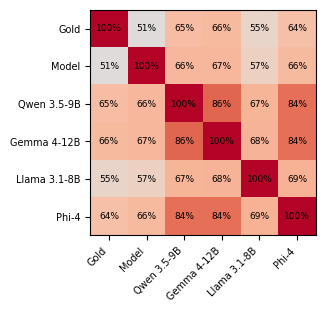

In [10]:
# Stack prompt types so each judge has one prediction column. Thinking and
# non-thinking runs are kept as separate judge labels when both are present.
sample_key = ['dataset', 'model', 'classes_subset', 'seed', 'cache_n', 'sample_index']
judge_long = wide.melt(
    id_vars=['judge', 'thinking', *sample_key],
    value_vars=PROMPT_COLUMNS,
    var_name='prompt_type',
    value_name='prediction',
)
judge_long['judge_label'] = judge_long['judge'] + np.where(
    judge_long['thinking'].astype(bool), ' [thinking]', ''
)
judge_long = judge_long.dropna(subset=['prediction']).copy()

judge_wide = (
    judge_long.pivot_table(
        index=[*sample_key, 'prompt_type'],
        columns='judge_label',
        values='prediction',
        aggfunc='last',
    )
    .reset_index()
)

targets = (
    wide[[*sample_key, 'real_label', 'model_prediction']]
    .drop_duplicates(subset=sample_key, keep='last')
)
judge_wide = judge_wide.merge(targets, on=sample_key, how='left')
judge_columns = sorted(judge_long['judge_label'].unique())
judge_matrix_columns = ['real_label', 'model_prediction', *judge_columns]
for column in judge_matrix_columns:
    judge_wide[column] = pd.to_numeric(judge_wide[column], errors='coerce').astype('Int64')

judge_matrix = exact_agreement_matrix(
    judge_wide,
    label_columns=judge_matrix_columns,
    strata_columns=('dataset', 'classes_subset', 'prompt_type'),
)
plot_agreement_matrix(judge_matrix, output_slug='judges_summary')